# 03 · Magnetic navigation: EKF vs particle filter

This notebook builds the full navigation pipeline from `magnavlab` primitives — flight/map loading, Tolles-Lawson compensation, INS simulation and the navigation filter — and compares an Extended Kalman Filter with a particle filter.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## 1. Load the flight and map, select a survey line (1003.02), decimate 10 → 2 Hz

In [2]:
%matplotlib inline
import numpy as np
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab import data, viz
from magnavlab.calibration import BuiltinTL
from magnavlab.ins import simulate_ins_velocity
from magnavlab.filters import EKFNav, ParticleFilterNav
from magnavlab.interfaces import NavProblem, NavResult
from magnavlab.metrics import summary

nav = load_flight('data/Flt1003_train.h5')
mag_map = load_map('data/maps/Eastern_395.h5')
idx = segment_indices(nav, 50713.0, 54497.0)[::5]
dt = nav.dt * 5
lat = np.radians(nav.get('lat')[idx]); lon = np.radians(nav.get('lon')[idx])
alt = nav.get('alt')[idx]; tt = nav.get('tt')[idx]
print(f'{idx.size} samples @ {1/dt:.0f} Hz')

7569 samples @ 2 Hz


## 2. Tolles-Lawson compensation of a cabin magnetometer
Fit on the Flt1002 maneuver segments, apply to the noisy `mag_4_uc` on the nav flight.

In [3]:
cal_flight = load_flight('data/Flt1002_train.h5')
cal_idx = np.concatenate([segment_indices(cal_flight, a, b) for a, b in data.CAL_SEGMENTS['Flt1002']])
calibrator = BuiltinTL().fit(cal_flight.flux(cal_idx), cal_flight.get('mag_4_uc')[cal_idx], cal_flight.dt)
measurement = calibrator.compensate(nav.flux(idx), nav.get('mag_4_uc')[idx], dt) - nav.get('diurnal')[idx]

## 3. Reference the measurement to the map (remove constant offset; estimate noise)

In [4]:
map_along = mag_map.value(lat, lon); valid = np.isfinite(map_along)
measurement = measurement - np.median(measurement[valid] - map_along[valid])
resid = (measurement - map_along)[valid]
sigma_meas = max(1.4826 * np.median(np.abs(resid - np.median(resid))), 5.0)
print(f'corr(measurement, map)={np.corrcoef(measurement[valid], map_along[valid])[0,1]:.3f}, sigma_meas={sigma_meas:.1f} nT')

corr(measurement, map)=0.966, sigma_meas=84.7 nT


## 4. Simulate a drifting INS (velocity-level error)

In [5]:
ins_lat, ins_lon, vN, vE = simulate_ins_velocity(lat, lon, alt, dt, seed=0)
problem = NavProblem(dt=dt, map=mag_map, lat=ins_lat, lon=ins_lon, alt=alt,
                     vN=vN, vE=vE, vD=np.zeros(idx.size), meas=measurement)

## 5. Run the filters (both implement the `NavFilter` protocol)

In [6]:
ekf = EKFNav(sigma_meas=sigma_meas).run(problem)
pf  = ParticleFilterNav(sigma_meas=sigma_meas).run(problem)
ins_result = NavResult(lat=ins_lat, lon=ins_lon)
for name, result in [('INS', ins_result), ('EKF', ekf), ('PF', pf)]:
    m = summary(result, lat, lon)
    print(f"{name:4s} DRMS={m['drms']:7.1f} m  CEP50={m['cep50']:6.1f}  CEP95={m['cep95']:6.1f}")

INS  DRMS=  575.6 m  CEP50= 501.9  CEP95= 941.5
EKF  DRMS=  101.3 m  CEP50=  92.1  CEP95= 158.8
PF   DRMS=  293.4 m  CEP50= 294.5  CEP95= 400.9


## 6. MagNav position vs truth, overlaid on the anomaly map
Estimated tracks against the true (GPS) path over the local anomaly field, zoomed tight (the free-INS solution is omitted — its kilometre-scale drift would flatten the comparison).

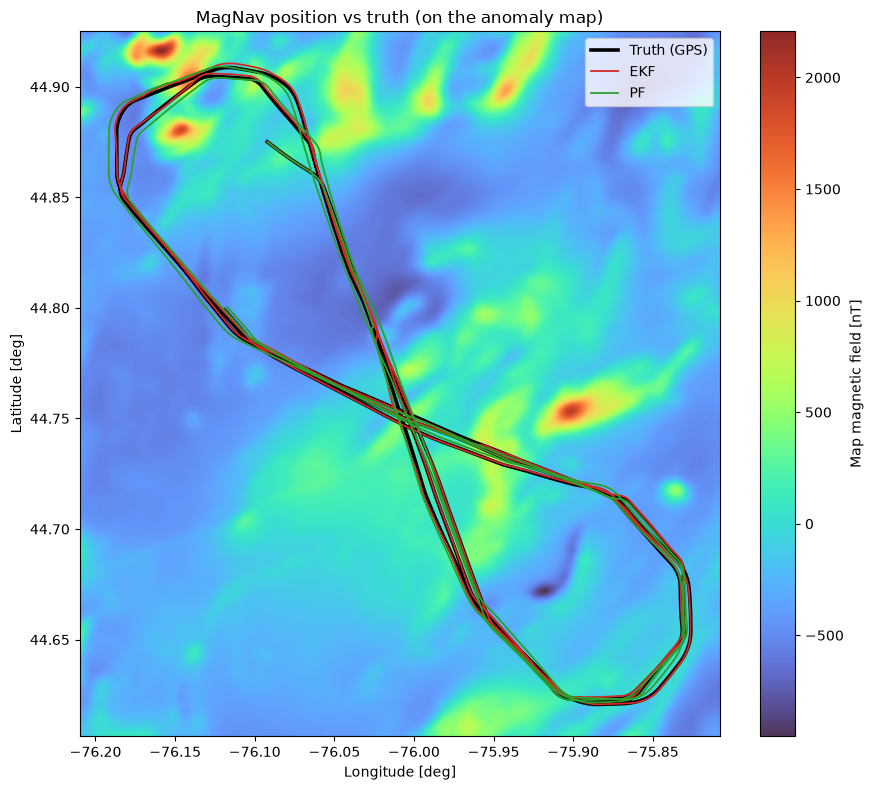

In [7]:
viz.plot_tracks_vs_truth(mag_map, lat, lon, {'EKF': (ekf, 'tab:red'), 'PF': (pf, 'tab:green')});

## 7. Position error over time

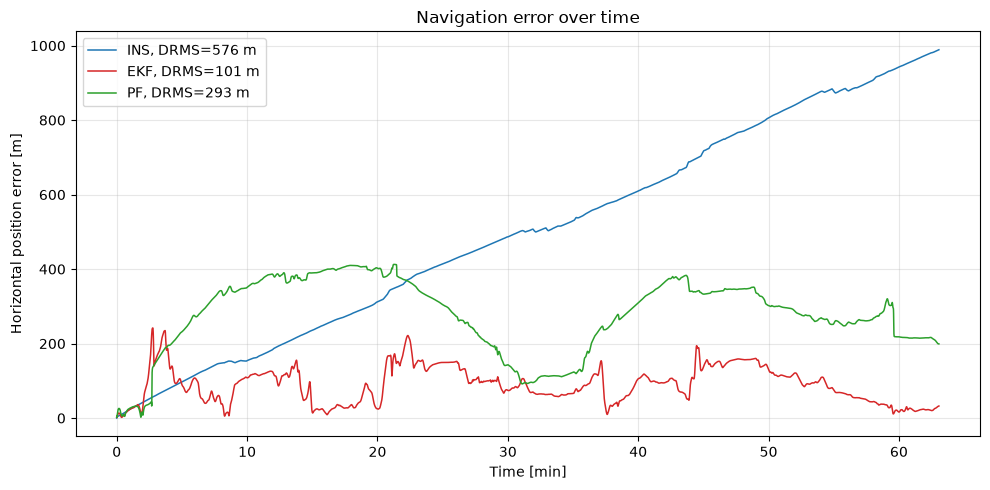

In [8]:
viz.plot_error_time(tt, lat, lon,
    {'INS': (ins_result,'tab:blue'), 'EKF': (ekf,'tab:red'), 'PF': (pf,'tab:green')});